## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [5]:
import pandas as pd
alc_consumption = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
alc_consumption.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [6]:
alc_consumption = alc_consumption.drop(columns=['total_litres_of_pure_alcohol'])
tidy_df = alc_consumption.melt(id_vars='country', var_name= 'drink', value_name='servings')
tidy_df.head()

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [9]:
tidy_df['drink']= tidy_df['drink'].str.split("_").str[0]
tidy_df.head()

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
top10_countries = tidy_df.sort_values(by=['drink','servings'], ascending=[True,False]).groupby('drink').head(10)
top10_countries


,country,drink,servings
117,Namibia,beer,376
45,Czech Republic,beer,361
62,Gabon,beer,347
65,Germany,beer,346
98,Lithuania,beer,343
135,Poland,beer,343
188,Venezuela,beer,333
81,Ireland,beer,313
129,Palau,beer,306
140,Romania,beer,297


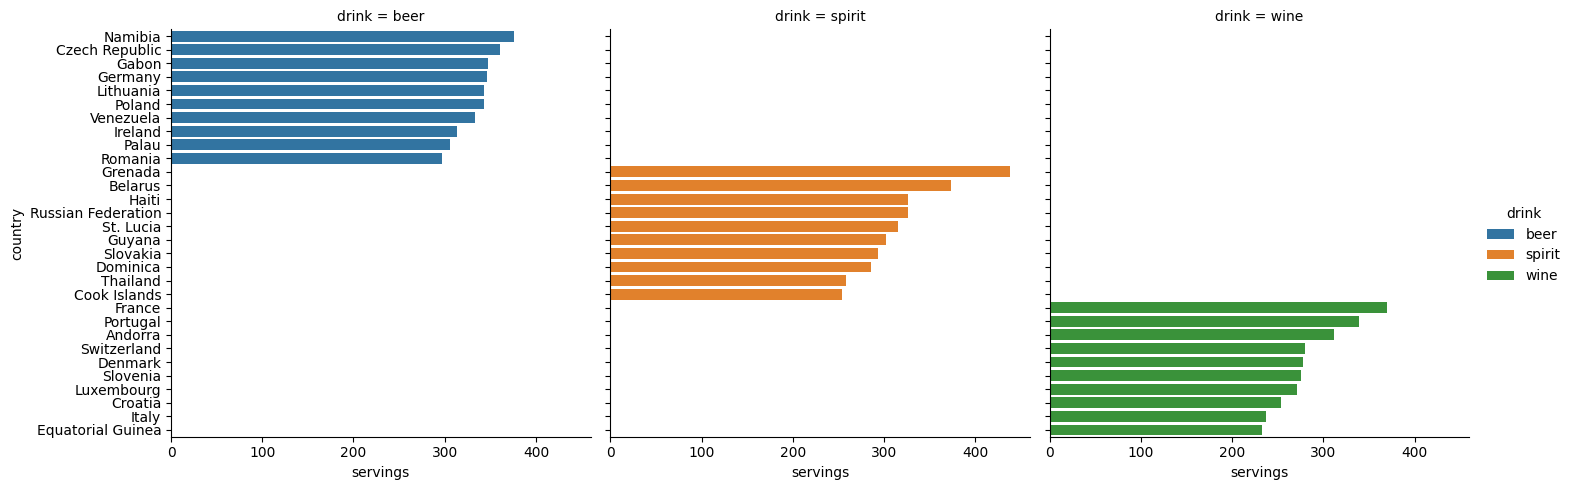

In [20]:
sns.catplot(
    data=top10_countries,
    x='servings',
    y='country',
    hue='drink',
    col='drink',
    kind='bar'
)

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [30]:
pd.pivot_table(tidy_df, values=['servings'], columns='country', index=['drink'])

servings                                                   \
country Afghanistan Albania Algeria Andorra Angola Antigua & Barbuda   
drink                                                                  
beer              0      89      25     245    217               102   
spirit            0     132       0     138     57               128   
wine              0      54      14     312     45                45   

                                             ...                       \
country Argentina Armenia Australia Austria  ... United Arab Emirates   
drink                                        ...                        
beer          193      21       261     279  ...                   16   
spirit         25     179        72      75  ...                  135   
wine          221      11       212     191  ...                    5   

                                                                           \
country United Kingdom Uruguay Uzbekistan Vanuatu Venezuela Vietnam Yemen   
drink                                                                       
beer               219     115         25      21       333     111     6   
spirit             126      35        101      18       100       2     0   
wine               195     220          8      11         3       1     0   

                         
country Zambia Zimbabwe  
drink                    
beer        32       64  
spirit      19       18  
wine         4        4  

[3 rows x 193 columns]